# 3. Seed variance and ablations

**Read this before believing any improvement in notebook 2.** The same
configuration trained at three seeds gives a spread; a difference between two
single runs is inside noise unless it exceeds `sqrt(2) x sd`.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "2")
import sys
sys.path.insert(0, "../src")
import numpy as np, pandas as pd, torch
torch.set_num_threads(2)
import matplotlib.pyplot as plt
pd.set_option("display.width", 130)


In [2]:
T = '../results/tables/'
noise = pd.read_csv(T+'seed_variance.csv')
noise[noise.split=='test_id'].round(5).to_string(index=False)

'  split                   metric  n_seeds    mean      sd     min     max  spread  diff_noise_scale\ntest_id                      mae        3 0.01509 0.00048 0.01461 0.01558 0.00097           0.00069\ntest_id        mae_nonzero_truth        3 0.17456 0.01534 0.15849 0.18905 0.03056           0.02170\ntest_id                     rmse        3 0.05850 0.00482 0.05350 0.06311 0.00961           0.00681\ntest_id          spearman_pooled        3 0.35550 0.00201 0.35328 0.35720 0.00392           0.00285\ntest_id spearman_within_scenario        3 0.58025 0.03032 0.54911 0.60968 0.06057           0.04288\ntest_id           top1_agreement        3 0.52778 0.09845 0.41667 0.60417 0.18750           0.13924'

The `diff_noise_scale` column is the bar every claimed gain has to clear.

In [3]:
runs = pd.read_csv(T+'seed_runs.csv')
piv = runs[runs.split=='test_id'].pivot(index='metric', columns='seed', values='value')
piv.round(5)

seed,0,7,1337
metric,,,
mae,0.01461,0.01509,0.01558
mae_nonzero_truth,0.15849,0.17616,0.18905
rmse,0.05350,0.05889,0.06311
spearman_pooled,0.35603,0.35720,0.35328
spearman_within_scenario,0.58196,0.60968,0.54911
top1_agreement,0.56250,0.60417,0.41667


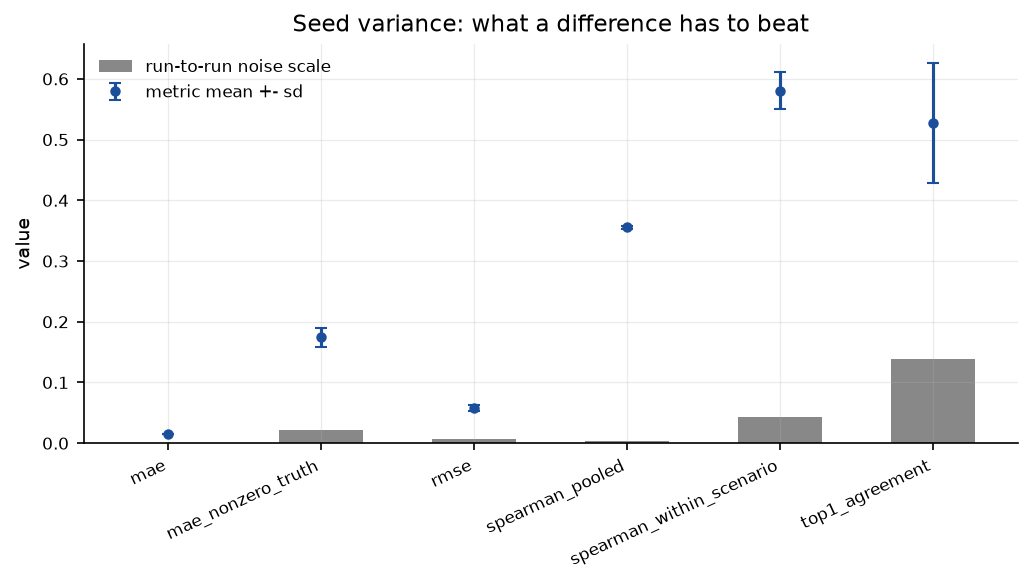

In [4]:
from IPython.display import Image, display
import os
if os.path.exists('../results/figures/seed_noise.png'):
    display(Image(filename='../results/figures/seed_noise.png'))

## Ablations: one mechanism removed at a time

`no_message_passing` is the one that isolates the graph. Its parameter count is
matched to the full model on purpose, so the comparison is about message
passing rather than about capacity.

In [5]:
abl = pd.read_csv(T+'ablations.csv')
p = abl[abl.split=='test_id'].set_index('variant')[['params','mae','spearman_within_scenario','train_seconds']]
p.round(4)

,params,mae,spearman_within_scenario,train_seconds
variant,,,,
full,55752,0.0146,0.5824,144.8070
no_message_passing,57160,0.0174,0.4018,49.0723
one_hop,27848,0.0158,0.5354,62.0205
unidirectional,38280,0.0158,0.5801,73.8684
no_edge_features,52200,0.0158,0.5865,117.4300
linear_traj_decoder,50671,0.0144,0.5678,124.8070


In [6]:
st = pd.read_csv(T+'ablation_statistics.csv')
st[st.split=='test_id'][['name_a','mean_a','mean_b','difference','p_adjusted','significant']].round(5).to_string(index=False)

'                       name_a  mean_a  mean_b  difference  p_adjusted  significant\n no_message_passing.abs_error 0.01740 0.01458     0.00282         0.0         True\n            one_hop.abs_error 0.01585 0.01458     0.00127         0.0         True\n     unidirectional.abs_error 0.01585 0.01458     0.00127         1.0        False\n   no_edge_features.abs_error 0.01584 0.01458     0.00126         1.0        False\nlinear_traj_decoder.abs_error 0.01437 0.01458    -0.00021         0.0         True'

### Placing each ablation against the noise scale

A significant paired p-value is not enough: the delta also has to be large
relative to seed-to-seed variation of the identical configuration.

In [7]:
from sndsur.metrics.stats import noise_scale, noise_verdict
ns = noise_scale('mae', runs[(runs.split=='test_id')&(runs.metric=='mae')].value.values)
full = float(abl[(abl.split=='test_id')&(abl.variant=='full')].mae.iloc[0])
rows = []
for _, r in abl[abl.split=='test_id'].iterrows():
    if r.variant == 'full': continue
    gain = float(r.mae) - full  # positive = removing it hurt
    ratio, verdict = noise_verdict(gain, ns)
    rows.append({'variant': r.variant, 'mae': round(float(r.mae),5),
                 'delta_vs_full': round(gain,5), 'ratio_to_noise': round(ratio,2),
                 'verdict': verdict})
pd.DataFrame(rows)

,variant,mae,delta_vs_full,ratio_to_noise,verdict
0,no_message_passing,0.01740,0.00282,4.11,survives
1,one_hop,0.01585,0.00127,1.85,suggestive
2,unidirectional,0.01585,0.00127,1.85,suggestive
3,no_edge_features,0.01584,0.00126,1.84,suggestive
4,linear_traj_decoder,0.01437,-0.00021,-0.31,inside noise
